# 허위매물 온도 분석  

---

In [7]:
import pandas as pd
import json
import glob
import os

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

print("="*60)
print("지역별 허위매물 온도 분석 시작")
print("="*60)

지역별 허위매물 온도 분석 시작


# 부동산 중개업소

In [25]:
# 1. 서울시 부동산 중개업소 정보 JSON 읽기
with open('../data/regionTemp/saleLand/서울시 부동산 중개업소 정보.json', 'r', encoding='utf-8') as f:
    broker_data = json.load(f)

broker_df = pd.DataFrame(broker_data['DATA'])
print("=== 서울시 부동산 중개업소 정보 ===")
print(f"데이터 shape: {broker_df.shape}")
print(broker_df.head())

=== 서울시 부동산 중개업소 정보 ===
데이터 shape: (25450, 21)
  pbadms_dsps_end_dd pbadms_dsps_strt_dd stts_se sgg_cd mdt_bsns_nm  \
0               None                None     영업중  11440         김은정   
1               None                None     영업중  11680         오해숙   
2               None                None     영업중  11680         양신숙   
3               None                None     영업중  11680         정경표   
4               None                None     영업중  11680         박규리   

        sys_reg_no   sno                                              telno  \
0  114402022000106  0000                                        02-718-3636   
1  116802022000266  0000                                      , 02-562-6985   
2  116802022000269  0000                                        02-572-8880   
3  116802022000259  0019                                        02-552-0113   
4  116802022000253  0000  02-512-2232, 02-547-2227, 02-518-2232, 02-515-...   

  lotno_se                                         

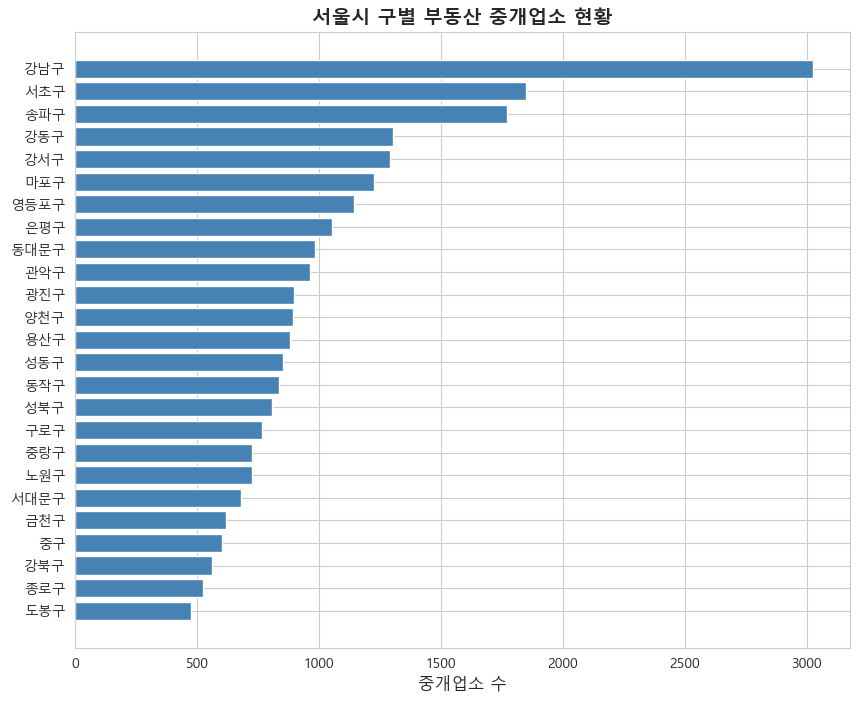

In [10]:
# 구 이름 추출
broker_df['region'] = broker_df['addr'].str.extract(r'서울특별시\s*(\S+구)')

# 구별 집계
broker_by_region = broker_df.groupby('region').size().reset_index(name='broker_count')

plt.figure(figsize=(10, 8))
plt.rcParams['font.family'] = 'Malgun Gothic'
broker_sorted = broker_by_region.sort_values('broker_count', ascending=False)
plt.barh(broker_sorted['region'], broker_sorted['broker_count'], color='steelblue')
plt.xlabel('중개업소 수', fontsize=12)
plt.title('서울시 구별 부동산 중개업소 현황', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.show()


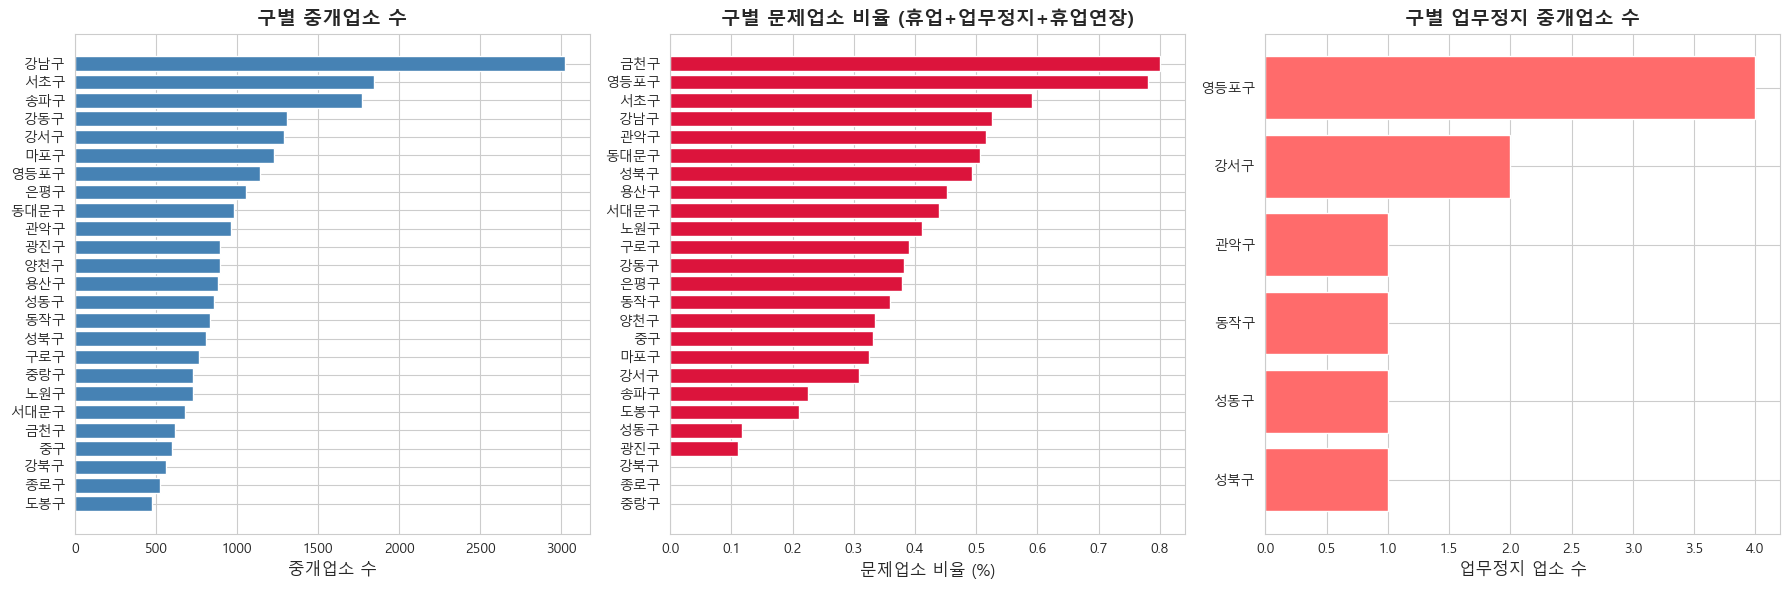


=== 중개업소 영업 상태 통계 ===
총 중개업소: 25,450개
영업중: 25,350개 (99.61%)
휴업: 86개
업무정지: 10개
휴업연장: 4개

=== 구별 문제업소 비율 TOP 10 ===
stts_se  문제업소    문제업소비율
region                 
금천구         5  0.801282
영등포구        9  0.781250
서초구        11  0.592034
강남구        16  0.525797
관악구         5  0.516529
동대문구        5  0.506586
성북구         4  0.493827
용산구         4  0.451977
서대문구        3  0.439239
노원구         3  0.411523

=== 업무정지 업소가 있는 구 ===
region
영등포구    4
강서구     2
관악구     1
동작구     1
성동구     1
성북구     1
dtype: int64


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 구 이름 추출
broker_df['region'] = broker_df['addr'].str.extract(r'서울특별시\s*(\S+구)')

# 그래프 (원 그래프 제외)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. 구별 중개업소 수
broker_by_region = broker_df.groupby('region').size().reset_index(name='total_count')
broker_sorted = broker_by_region.sort_values('total_count', ascending=False)
axes[0].barh(broker_sorted['region'], broker_sorted['total_count'], color='steelblue')
axes[0].set_xlabel('중개업소 수', fontsize=12)
axes[0].set_title('구별 중개업소 수', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# 2. 구별 문제 있는 업소 비율 (휴업+업무정지+휴업연장)
status_by_region = broker_df.groupby(['region', 'stts_se']).size().unstack(fill_value=0)
status_by_region['문제업소'] = status_by_region.get('휴업', 0) + status_by_region.get('업무정지', 0) + status_by_region.get('휴업연장', 0)
status_by_region['문제업소비율'] = status_by_region['문제업소'] / status_by_region.sum(axis=1) * 100

problem_sorted = status_by_region['문제업소비율'].sort_values(ascending=False)
axes[1].barh(problem_sorted.index, problem_sorted.values, color='crimson')
axes[1].set_xlabel('문제업소 비율 (%)', fontsize=12)
axes[1].set_title('구별 문제업소 비율 (휴업+업무정지+휴업연장)', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

# 3. 구별 업무정지 업소 수
suspension_by_region = broker_df[broker_df['stts_se'] == '업무정지'].groupby('region').size().sort_values(ascending=False)
if len(suspension_by_region) > 0:
    axes[2].barh(suspension_by_region.index, suspension_by_region.values, color='#ff6b6b')
    axes[2].set_xlabel('업무정지 업소 수', fontsize=12)
    axes[2].set_title('구별 업무정지 중개업소 수', fontsize=14, fontweight='bold')
    axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== 중개업소 영업 상태 통계 ===")
print(f"총 중개업소: {len(broker_df):,}개")
print(f"영업중: {(broker_df['stts_se']=='영업중').sum():,}개 ({(broker_df['stts_se']=='영업중').sum()/len(broker_df)*100:.2f}%)")
print(f"휴업: {(broker_df['stts_se']=='휴업').sum()}개")
print(f"업무정지: {(broker_df['stts_se']=='업무정지').sum()}개")
print(f"휴업연장: {(broker_df['stts_se']=='휴업연장').sum()}개")

print("\n=== 구별 문제업소 비율 TOP 10 ===")
print(status_by_region[['문제업소', '문제업소비율']].sort_values('문제업소비율', ascending=False).head(10))

print("\n=== 업무정지 업소가 있는 구 ===")
if len(suspension_by_region) > 0:
    print(suspension_by_region)


# 행정처분

In [24]:
# 2. 행정처분 CSV 읽기
try:
    penalty_df = pd.read_csv('../data/regionTemp/saleLand/행정처분.csv', encoding='utf-8')
except UnicodeDecodeError:
    try:
        penalty_df = pd.read_csv('../data/regionTemp/행정처분.csv', encoding='cp949')
    except UnicodeDecodeError:
        penalty_df = pd.read_csv('../data/regionTemp/행정처분.csv', encoding='euc-kr')

print("\n=== 행정처분 정보 ===")
print(f"데이터 shape: {penalty_df.shape}")
print(penalty_df.head())


=== 행정처분 정보 ===
데이터 shape: (3355, 10)
     년도  분기    시도명 시군구명  단속업소수  적발건수  고발센터신고건수  계  등록취소  업무정지
0  2017   1  서울특별시   중구      4     4         0  4     1     2
1  2017   1  서울특별시  성동구      0     1         1  1     0     1
2  2017   1  서울특별시  광진구      0     3         0  3     1     0
3  2017   1  서울특별시  중랑구      0     1         0  1     0     0
4  2017   1  서울특별시  강북구      0     2         0  2     1     1


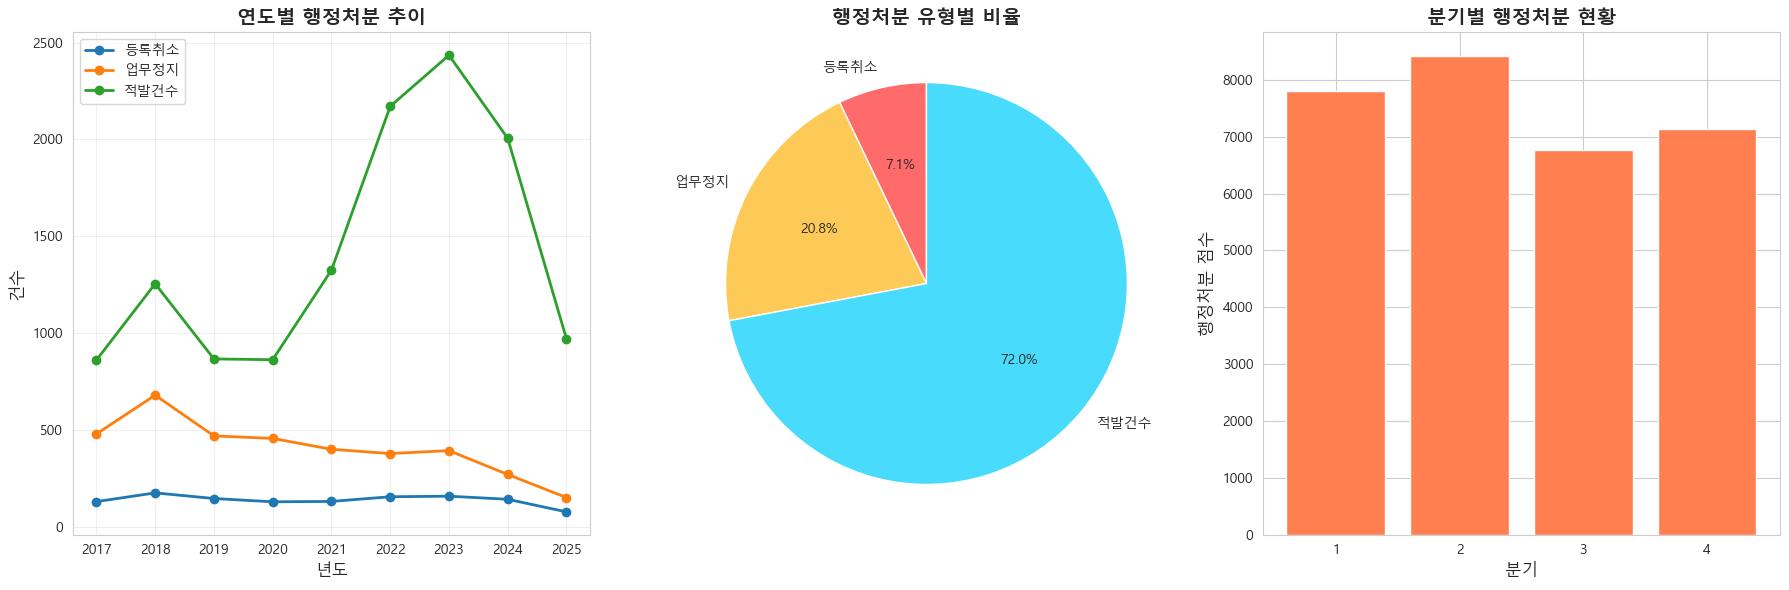

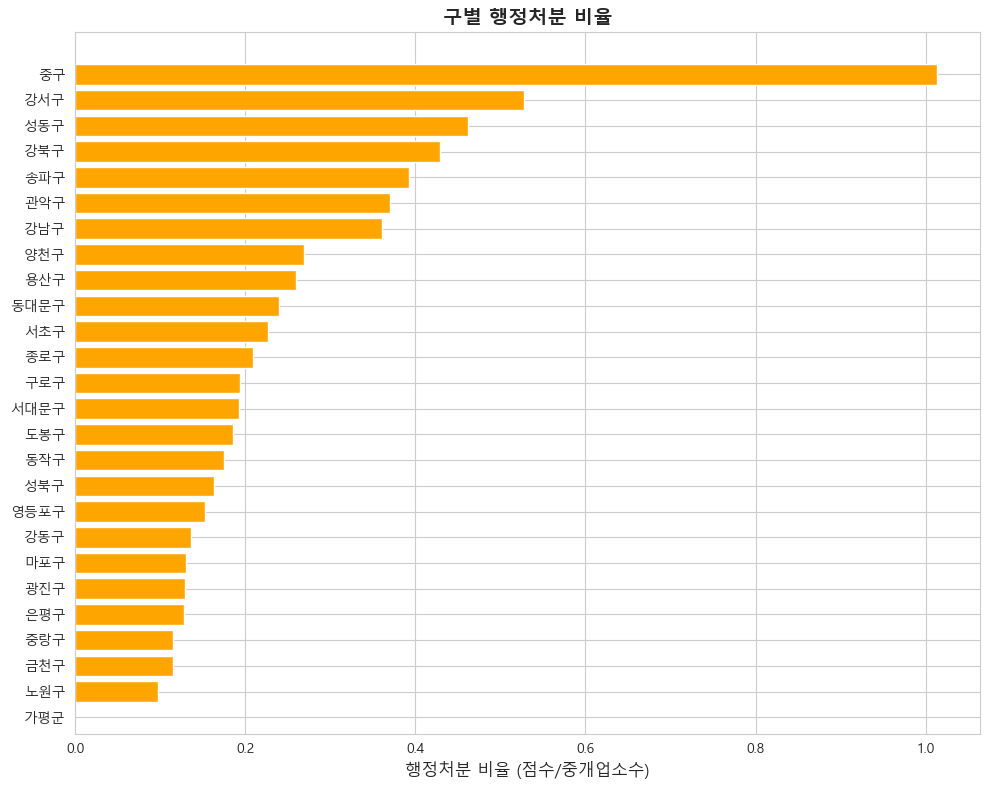


=== 행정처분 통계 ===
총 등록취소: 1261건
총 업무정지: 3693건
총 적발건수: 12759건
총 단속업소수: 5655개

연도별 통계:
      등록취소  업무정지  적발건수
년도                    
2017   132   481   862
2018   177   681  1256
2019   148   471   868
2020   131   458   864
2021   133   402  1326
2022   157   380  2171
2023   160   395  2435
2024   144   272  2006
2025    79   153   971

구별 행정처분 TOP 10:
시군구명
서구     1852
강남구    1092
화성시     917
구미시     817
김포시     791
송파구     695
강서구     681
동구      662
중구      608
평택시     602
Name: penalty_score, dtype: int64

구별 행정처분 비율 TOP 10:
    region  penalty_score  total_count  penalty_ratio
168     중구            608        600.0       1.013333
5      강서구            681       1291.0       0.527498
95     성동구            394        854.0       0.461358
4      강북구            241        562.0       0.428826
100    송파구            695       1772.0       0.392212
22     관악구            357        963.0       0.370717
1      강남구           1092       3027.0       0.360753
121    양천구            240        89

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 행정처분 점수 계산 (등록취소=5점, 업무정지=3점, 적발건수=1점)
penalty_df['penalty_score'] = (
    penalty_df['등록취소'] * 5 +
    penalty_df['업무정지'] * 3 +
    penalty_df['적발건수'] * 1
)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. 연도별 행정처분 추이
yearly_penalty = penalty_df.groupby('년도')[['등록취소', '업무정지', '적발건수']].sum()
yearly_penalty.plot(ax=axes[0], marker='o', linewidth=2)
axes[0].set_xlabel('년도', fontsize=12)
axes[0].set_ylabel('건수', fontsize=12)
axes[0].set_title('연도별 행정처분 추이', fontsize=14, fontweight='bold')
axes[0].legend(['등록취소', '업무정지', '적발건수'])
axes[0].grid(True, alpha=0.3)

# 2. 처분 유형별 비율
penalty_types = penalty_df[['등록취소', '업무정지', '적발건수']].sum()
colors = ['#ff6b6b', '#feca57', '#48dbfb']
axes[1].pie(penalty_types, labels=['등록취소', '업무정지', '적발건수'], 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('행정처분 유형별 비율', fontsize=14, fontweight='bold')

# 3. 분기별 행정처분 패턴
quarterly_penalty = penalty_df.groupby('분기')['penalty_score'].sum()
axes[2].bar(quarterly_penalty.index, quarterly_penalty.values, color='coral')
axes[2].set_xlabel('분기', fontsize=12)
axes[2].set_ylabel('행정처분 점수', fontsize=12)
axes[2].set_title('분기별 행정처분 현황', fontsize=14, fontweight='bold')
axes[2].set_xticks([1, 2, 3, 4])

plt.tight_layout()
plt.show()

# 구별 행정처분 비율 (중개업소 수 대비)
penalty_grouped = penalty_df.groupby('시군구명')['penalty_score'].sum().reset_index()
penalty_grouped.rename(columns={'시군구명': 'region'}, inplace=True)

# 중개업소 수와 병합
penalty_with_broker = penalty_grouped.merge(broker_by_region, on='region', how='left')
penalty_with_broker['penalty_ratio'] = penalty_with_broker['penalty_score'] / penalty_with_broker['total_count']
penalty_with_broker = penalty_with_broker.sort_values('penalty_ratio', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(penalty_with_broker['region'], penalty_with_broker['penalty_ratio'], color='orange')
plt.xlabel('행정처분 비율 (점수/중개업소수)', fontsize=12)
plt.title('구별 행정처분 비율', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== 행정처분 통계 ===")
print(f"총 등록취소: {penalty_df['등록취소'].sum()}건")
print(f"총 업무정지: {penalty_df['업무정지'].sum()}건")
print(f"총 적발건수: {penalty_df['적발건수'].sum()}건")
print(f"총 단속업소수: {penalty_df['단속업소수'].sum()}개")

print(f"\n연도별 통계:")
print(yearly_penalty)

penalty_by_region = penalty_df.groupby('시군구명')['penalty_score'].sum().sort_values(ascending=False)
print(f"\n구별 행정처분 TOP 10:")
print(penalty_by_region.head(10))

print(f"\n구별 행정처분 비율 TOP 10:")
print(penalty_with_broker[['region', 'penalty_score', 'total_count', 'penalty_ratio']].head(10))


# 경매 분석

In [19]:
# 3. 모든 구의 매각통계 파일 읽기
sale_files = glob.glob('../data/regionTemp/saleLand/지역별 매각통계_*.xls')

sale_dfs = []
for file_path in sale_files:
    region_name = os.path.basename(file_path).replace('지역별 매각통계_', '').replace('.xls', '')
    
    df = pd.read_excel(file_path, engine='xlrd')
    df['region'] = region_name
    sale_dfs.append(df)

sale_df = pd.concat(sale_dfs, ignore_index=True)

# 경매건수를 숫자로 변환
sale_df['경매건수'] = pd.to_numeric(sale_df['경매건수'], errors='coerce')

print("\n=== 지역별 매각통계 (전체 구) ===")
print(f"총 {len(sale_files)}개 구 데이터 로드 완료")
print(f"전체 데이터 shape: {sale_df.shape}")

# 구별 경매건수 확인
print("\n구별 경매건수:")
region_auction = sale_df.groupby('region')['경매건수'].sum().sort_values(ascending=False)
for region, count in region_auction.items():
    print(f"  {region}: {int(count)}건")



=== 지역별 매각통계 (전체 구) ===
총 25개 구 데이터 로드 완료
전체 데이터 shape: (353, 8)

구별 경매건수:
  구로구: 1960건
  성북구: 1800건
  관악구: 1754건
  동작구: 1754건
  중랑구: 1694건
  강북구: 1636건
  금천구: 1550건
  도봉구: 1538건
  송파구: 1502건
  은평구: 1345건
  서초구: 1338건
  서대문구: 1324건
  중구: 1252건
  강남구: 1250건
  강서구: 1173건
  강동구: 1166건
  영등포구: 1114건
  마포구: 998건
  노원구: 994건
  동대문구: 980건
  광진구: 866건
  양천구: 752건
  종로구: 718건
  성동구: 520건
  용산구: 372건


경매 데이터가 있는 구: 25개
   region    경매건수
6     구로구  1960.0
16    성북구  1800.0
4     관악구  1754.0
11    동작구  1754.0
24    중랑구  1694.0
2     강북구  1636.0
7     금천구  1550.0
9     도봉구  1538.0
17    송파구  1502.0
21    은평구  1345.0
14    서초구  1338.0
13   서대문구  1324.0
23     중구  1252.0
0     강남구  1250.0
3     강서구  1173.0
1     강동구  1166.0
19   영등포구  1114.0
12    마포구   998.0
8     노원구   994.0
10   동대문구   980.0
5     광진구   866.0
18    양천구   752.0
22    종로구   718.0
15    성동구   520.0
20    용산구   372.0


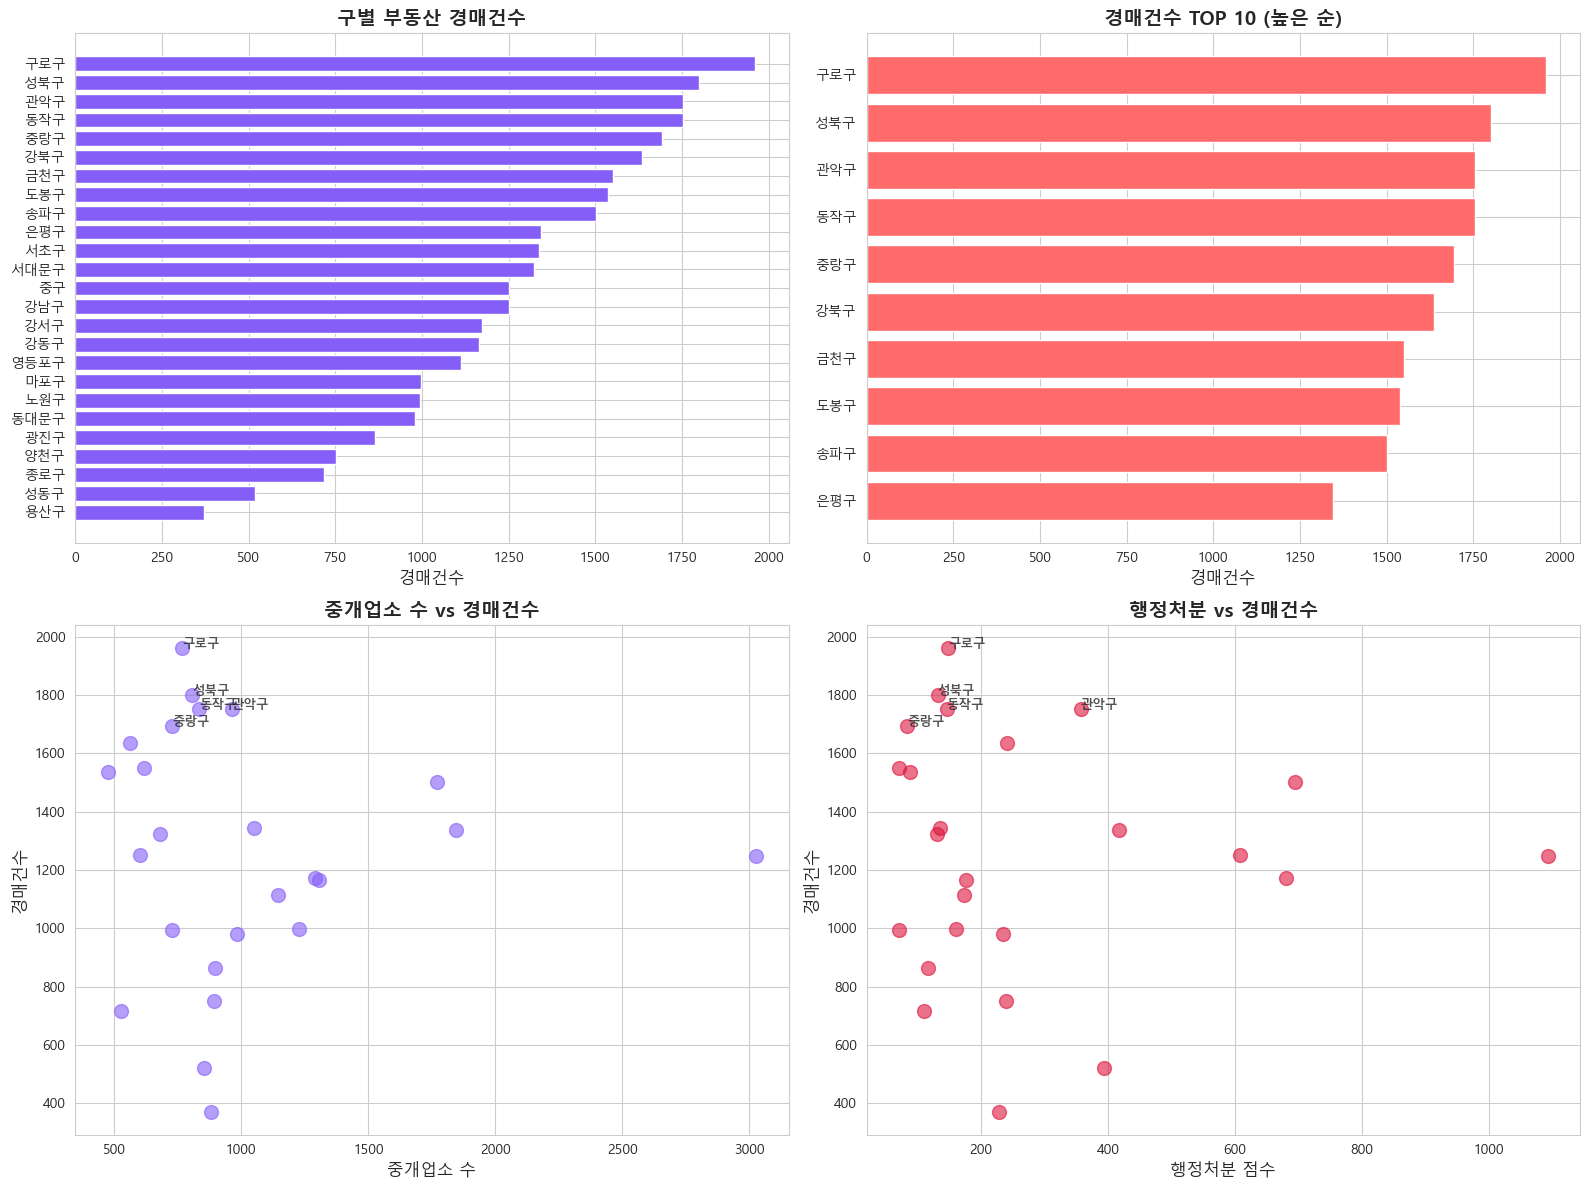


=== 경매 통계 ===
총 경매건수: 31350건
평균 (구당): 1254건
최대: 1960건 (구로구)
최소: 372건 (용산구)

중개업소 수 vs 경매건수 상관계수: -0.032
행정처분 vs 경매건수 상관계수: -0.043


In [21]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 구별 경매건수 집계
auction_by_region = sale_df.groupby('region')['경매건수'].sum().reset_index()
auction_by_region = auction_by_region.sort_values('경매건수', ascending=False)

print(f"경매 데이터가 있는 구: {len(auction_by_region)}개")
print(auction_by_region)

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 구별 경매건수
axes[0, 0].barh(auction_by_region['region'], auction_by_region['경매건수'], color='#845ef7')
axes[0, 0].set_xlabel('경매건수', fontsize=12)
axes[0, 0].set_title('구별 부동산 경매건수', fontsize=14, fontweight='bold')
axes[0, 0].invert_yaxis()

# 2. 경매건수 TOP 10 vs BOTTOM 10 비교
top10 = auction_by_region.head(10)
bottom10 = auction_by_region.tail(10).sort_values('경매건수', ascending=True)

x = range(len(top10))
axes[0, 1].barh(top10['region'], top10['경매건수'], color='#ff6b6b', label='TOP 10')
axes[0, 1].set_xlabel('경매건수', fontsize=12)
axes[0, 1].set_title('경매건수 TOP 10 (높은 순)', fontsize=14, fontweight='bold')
axes[0, 1].invert_yaxis()

# 3. 경매건수 vs 중개업소 수
merged_auction = auction_by_region.merge(broker_by_region, on='region', how='left')
axes[1, 0].scatter(merged_auction['total_count'], merged_auction['경매건수'], 
                   s=100, alpha=0.6, color='#845ef7')
axes[1, 0].set_xlabel('중개업소 수', fontsize=12)
axes[1, 0].set_ylabel('경매건수', fontsize=12)
axes[1, 0].set_title('중개업소 수 vs 경매건수', fontsize=14, fontweight='bold')

# 구 이름 표시 (TOP 5만)
top5_auction = merged_auction.nlargest(5, '경매건수')
for idx, row in top5_auction.iterrows():
    axes[1, 0].annotate(row['region'], (row['total_count'], row['경매건수']), 
                        fontsize=9, alpha=0.8, fontweight='bold')

# 4. 경매건수 vs 행정처분
penalty_grouped = penalty_df.groupby('시군구명')['penalty_score'].sum().reset_index()
penalty_grouped.rename(columns={'시군구명': 'region'}, inplace=True)

merged_all = auction_by_region.merge(penalty_grouped, on='region', how='left')
axes[1, 1].scatter(merged_all['penalty_score'], merged_all['경매건수'], 
                   s=100, alpha=0.6, color='crimson')
axes[1, 1].set_xlabel('행정처분 점수', fontsize=12)
axes[1, 1].set_ylabel('경매건수', fontsize=12)
axes[1, 1].set_title('행정처분 vs 경매건수', fontsize=14, fontweight='bold')

# 구 이름 표시 (TOP 5만)
for idx, row in top5_auction.iterrows():
    matched = merged_all[merged_all['region'] == row['region']]
    if not matched.empty:
        axes[1, 1].annotate(row['region'], 
                           (matched.iloc[0]['penalty_score'], matched.iloc[0]['경매건수']), 
                           fontsize=9, alpha=0.8, fontweight='bold')

plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== 경매 통계 ===")
print(f"총 경매건수: {auction_by_region['경매건수'].sum():.0f}건")
print(f"평균 (구당): {auction_by_region['경매건수'].mean():.0f}건")
print(f"최대: {auction_by_region['경매건수'].max():.0f}건 ({auction_by_region.loc[auction_by_region['경매건수'].idxmax(), 'region']})")
print(f"최소: {auction_by_region['경매건수'].min():.0f}건 ({auction_by_region.loc[auction_by_region['경매건수'].idxmin(), 'region']})")

# 상관계수
corr_broker = merged_auction['total_count'].corr(merged_auction['경매건수'])
print(f"\n중개업소 수 vs 경매건수 상관계수: {corr_broker:.3f}")

corr_penalty = merged_all['penalty_score'].corr(merged_all['경매건수'])
print(f"행정처분 vs 경매건수 상관계수: {corr_penalty:.3f}")


# 허위매물 안전온도 계산

In [23]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("="*60)
print("허위매물 온도 계산")
print("="*60)

# 1. 모든 지표 병합
# 중개업소 수
broker_count = broker_by_region.rename(columns={'total_count': 'broker_count'})

# 행정처분 점수
penalty_grouped = penalty_df.groupby('시군구명')['penalty_score'].sum().reset_index()
penalty_grouped.rename(columns={'시군구명': 'region'}, inplace=True)

# 경매건수
auction_grouped = auction_by_region.copy()

# 문제업소 비율
problem_ratio = status_by_region[['문제업소비율']].reset_index()

# 병합
merged = broker_count.copy()
merged = merged.merge(penalty_grouped, on='region', how='left')
merged = merged.merge(auction_grouped, on='region', how='left')
merged = merged.merge(problem_ratio, on='region', how='left')
merged = merged.fillna(0)

print(f"\n병합 완료: {len(merged)}개 지역")
print(merged.head())

# 2. 행정처분 비율 계산
merged['penalty_ratio'] = merged['penalty_score'] / merged['broker_count']

# 3. 정규화 (0-100 범위)
scaler = MinMaxScaler(feature_range=(0, 100))

merged['penalty_ratio_norm'] = scaler.fit_transform(merged[['penalty_ratio']])
merged['auction_norm'] = scaler.fit_transform(merged[['경매건수']])
merged['problem_norm'] = scaler.fit_transform(merged[['문제업소비율']])

# 4. 허위매물 온도 계산 (가중 평균)
# 행정처분 비율 40%, 경매건수 30%, 문제업소 비율 30%
merged['fake_temperature'] = (
    merged['penalty_ratio_norm'] * 0.40 +
    merged['auction_norm'] * 0.30 +
    merged['problem_norm'] * 0.30
)

# 5. 등급 분류
def fake_grade(temp):
    if pd.isna(temp):
        return 'N/A'
    elif temp < 33:
        return '안전'
    elif temp < 66:
        return '주의'
    else:
        return '고위험'

merged['grade'] = merged['fake_temperature'].apply(fake_grade)

print("\n✓ 허위매물 온도 계산 완료!")
print("\n지역별 허위매물 온도:")
result = merged[['region', 'broker_count', 'penalty_score', '경매건수', '문제업소비율', 'fake_temperature', 'grade']].sort_values('fake_temperature', ascending=False)
print(result)


허위매물 온도 계산

병합 완료: 25개 지역
  region  broker_count  penalty_score    경매건수    문제업소비율
0    강남구          3027           1092  1250.0  0.525797
1    강동구          1305            177  1166.0  0.381679
2    강북구           562            241  1636.0  0.000000
3    강서구          1291            681  1173.0  0.308880
4    관악구           963            357  1754.0  0.516529

✓ 허위매물 온도 계산 완료!

지역별 허위매물 온도:
   region  broker_count  penalty_score    경매건수    문제업소비율  fake_temperature  \
23     중구           600            608  1252.0  0.332226         69.063223   
4     관악구           963            357  1754.0  0.516529         57.371100   
7     금천구           619             71  1550.0  0.801282         52.992990   
6     구로구           766            148  1960.0  0.390117         48.774697   
16    성북구           806            132  1800.0  0.493827         48.348704   
0     강남구          3027           1092  1250.0  0.525797         47.761385   
14    서초구          1847            418  1338.0  0.592034    